In [1]:
#Bibliotecas

import pandas as pd 
import pybioportal as pybio
from pybioportal import clinical_data as cd
import requests
from pybioportal import clinical_attributes as ca
import json
import os
from category_encoders.one_hot import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import RocCurveDisplay
from tabpfn import TabPFNClassifier
import shap
import optuna
import seaborn as sns
import matplotlib.pyplot as plt

/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import clone

In [3]:
import joblib

In [4]:
from sklearn.base import clone as sk_clone

### Baixar via API

In [ ]:
df = ca.fetch_clinical_attributes(study_ids=["coadread_tcga"])

attribute_ids=["OS_STATUS", "OS_MONTHS", "RACE"]

df_c=cd.fetch_all_clinical_data_in_study(study_id="coadread_tcga",
                                       attribute_ids=attribute_ids,
                                       clinical_data_type="PATIENT", 
                                       ret_format="WIDE")

In [3]:
# Endpoint de consulta para o GDC
api_url = 'https://api.gdc.cancer.gov/cases'

# Filtro para o projeto TCGA-COADREAD (colo e reto)
filters = {
    "op": "and",
    "content": [
        {"op": "in", "content": {"field": "cases.project.project_id", "value": ["TCGA-COAD", "TCGA-READ"]}},
    ]
}

# Parâmetros da query (quais campos buscar)
params = {
    "filters": json.dumps(filters),
    "fields": "submitter_id,diagnoses.age_at_diagnosis,demographic.gender", # IDs e dados clínicos
    "format": "json",
    "size": "2000" # Tenta buscar até 2000 casos
}

response = requests.get(api_url, params=params)
data = response.json()

# Converter o resultado para um DataFrame do Pandas
casos_tcga = [item['submitter_id'] for item in data['data']['hits']]
print(f"Número de casos TCGA-COAD/READ encontrados: {len(casos_tcga)}")

Número de casos TCGA-COAD/READ encontrados: 633


### Configuração das Variáveis

In [5]:
DIRETORIO_DOWNLOAD = "/mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/dados"  # Ajuste se for diferente
# O nome do arquivo manifesto que você usou
CAMINHO_MANIFESTO = "/mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/manifesto/gdc_manifest.2025-10-15.123035.txt"

# Nome do arquivo de saída (a matriz consolidada)
ARQUIVO_SAIDA = "/mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/dados/TCGA_COADREAD_RNAseq_Matrix.csv"

# O nome exato do arquivo de dados dentro de cada pasta UUID
# (Pode variar, ajuste conforme o nome do arquivo que você encontrar dentro da primeira pasta de UUID)
NOME_ARQUIVO_DADOS = "arquivo_de_expressao.tsv"

DIRETORIO_DOWNLOAD_ATLAS = "/mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/coadread_tcga_pan_can_atlas_2018"

#Diretório para baixar os dados clínicos
CAMINHO_CLINICO = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, 'data_clinical_patient.txt')

#Diretório para baixar os dados de RNA-seq
CAMINHO_RNASEQ = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, 'data_mrna_seq_v2_rsem.txt')
CAMINHO_CLINICO = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, 'data_clinical_patient.txt')
CAMINHO_SAMPLE = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, 'data_clinical_sample.txt')

#Diretório para baixar os dados de proteômicas
CAMINHO_RPPA = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, 'data_rppa.txt')

#Diretório para baixar os dados de metilação
CAMINHO_METHYLATION = os.path.join(DIRETORIO_DOWNLOAD_ATLAS , 'data_methylation_hm27_hm450_merged.txt')

#Diretorio de mutação
CAMINHO_MUTATIONS = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, 'data_mutations.txt')


### Baixando os Arquivos

#### Manifesto

In [6]:
# 1. Carregar o Manifesto e Mapear File ID para Sample ID
print(f"1. Carregando manifesto: {CAMINHO_MANIFESTO}")
# O manifesto mapeia o File ID (UUID) para o Sample ID (TCGA-XX-XXXX)
try:
    manifesto_df = pd.read_csv(CAMINHO_MANIFESTO, sep='\t')
    # O GDC usa 'id' para o UUID e 'filename' como o nome do arquivo
    # 'file_id' é o UUID, e 'case_submitter_id' é o Patient/Case ID
    mapeamento_ids = manifesto_df[['id', 'filename']].set_index('id')
except Exception as e:
    print(f"Erro ao carregar o manifesto. Certifique-se de que o caminho está correto e o separador é tab ('\\t'). Erro: {e}")
    exit()

1. Carregando manifesto: /mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/manifesto/gdc_manifest.2025-10-15.123035.txt


In [7]:
# 1. Carregar o Manifesto e Mapear File ID para Sample ID
print(f"1. Carregando manifesto: {CAMINHO_MANIFESTO}")

try:
    # Use 'sep=\t' (separador de tabulação) e 'header=0' para usar a primeira linha como cabeçalho
    manifesto_df = pd.read_csv(CAMINHO_MANIFESTO, sep='\t', header=0) 
    
    # Imprime as colunas para depuração:
    print("Colunas lidas no manifesto:")
    print(manifesto_df.columns.tolist()) 
    
    # Verifique se as colunas 'id' e 'filename' existem
    if 'id' in manifesto_df.columns and 'filename' in manifesto_df.columns:
        mapeamento_ids = manifesto_df[['id', 'filename']].set_index('id')
        print("Manifesto carregado com sucesso.")
    else:
        # Se as colunas não existirem, provavelmente houve um erro de leitura do cabeçalho
        raise KeyError("Colunas 'id' ou 'filename' não encontradas. Verifique o separador (sep='\\t') ou o cabeçalho (header=0).")

except KeyError as e:
    print(f"Erro: {e}. Verifique se as colunas do seu manifesto são realmente 'id' e 'filename'.")
    exit()
except Exception as e:
    print(f"Erro inesperado ao carregar o manifesto: {e}")
    exit()


1. Carregando manifesto: /mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/manifesto/gdc_manifest.2025-10-15.123035.txt
Colunas lidas no manifesto:
['id', 'filename', 'md5', 'size', 'state']
Manifesto carregado com sucesso.


#### Baixar Dados Clínicos 

In [8]:
print(f"Carregando dados clínicos de {CAMINHO_CLINICO}...")

try:
    # 1. Tentar pular as duas primeiras linhas (que são descrições e metadados)
    clinical_df = pd.read_csv(
        CAMINHO_CLINICO,
        sep='\t',
        header=0,    # Lê o cabeçalho na primeira linha do arquivo
        skiprows=4   # <--- CORREÇÃO: Tenta pular as primeiras 4 linhas (comum em arquivos cBioPortal)
    )
    
    # 2. Inspecionar e Ajustar o Nome da Coluna
    # No cBioPortal, o nome real da coluna do paciente é "PATIENT_ID" ou um sinônimo.
    # Se o nome da coluna não for 'PATIENT_ID', descubra qual é o correto.
    
    if 'PATIENT_ID' in clinical_df.columns:
        id_col = 'PATIENT_ID'
    elif 'PATIENT_ID' in clinical_df.iloc[0].values:
         # Se 'PATIENT_ID' for um valor na primeira linha (problema de header)
         id_col = clinical_df.columns[clinical_df.iloc[0].values == 'PATIENT_ID'][0]
         clinical_df = clinical_df.iloc[1:].set_axis(clinical_df.iloc[0].values, axis=1) # Reajusta o header
         id_col = 'PATIENT_ID' # Se o reajuste funcionou
    else:
        # Tenta a coluna mais provável para o ID do paciente
        id_col = '#Patient Identifier' # Outro nome comum no cBioPortal
        if id_col not in clinical_df.columns:
            # Se ainda não achar, vamos forçar o uso da primeira coluna, que quase sempre é o ID
            id_col = clinical_df.columns[0]
            print(f"AVISO: Coluna 'PATIENT_ID' não encontrada. Usando a primeira coluna: {id_col}")
            
    # 3. Configurar o índice
    clinical_df = clinical_df.set_index(id_col)
    
    print(f"Dados clínicos carregados. Dimensões: {clinical_df.shape}")
    
except Exception as e:
    print(f"ERRO FATAL ao carregar dados clínicos. Erro: {e}")
    # Adicione uma linha de depuração para ver as colunas lidas
    # print(f"Colunas lidas: {clinical_df.columns.tolist()}")
    exit()

# O restante do seu script (Passo 3) viria aqui...

Carregando dados clínicos de /mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/coadread_tcga_pan_can_atlas_2018/data_clinical_patient.txt...
Dados clínicos carregados. Dimensões: (594, 37)


#### Baixar Dados RNA-seq

In [9]:
def load_cbioportal_data(path, skiprows=4):
    """Carrega dados do formato cBioPortal, pulando linhas de metadados e usando o separador tab."""
    return pd.read_csv(path, sep='\t', header=0, skiprows=skiprows)

# ----------------------------------------------------------------------
# 1. CARREGAR TODOS OS DATASETS (Assumindo que os nomes dos arquivos estão corretos)
# ----------------------------------------------------------------------

# 1.1 RNA-Seq Data (Ômicas)
print("1.1 Carregando matriz de RNA-Seq...")
rna_seq_df = pd.read_csv(CAMINHO_RNASEQ, sep='\t', header=0, index_col=0)
rna_seq_df = rna_seq_df.drop(index='Entrez_Gene_Id', axis=0, errors='ignore')

# 1.2 Clinical Data (Patient Level)
print("1.2 Carregando dados clínicos (Patient Level)...")
clinical_patient_df = load_cbioportal_data(CAMINHO_CLINICO).set_index('PATIENT_ID')

# 1.3 Sample Data (Mapeamento Sample -> Patient)
print("1.3 Carregando dados de amostras (Sample Data) para mapeamento...")
clinical_sample_df = load_cbioportal_data(CAMINHO_SAMPLE)

# ----------------------------------------------------------------------
# 2. ALINHAMENTO E CONSOLIDAÇÃO
# ----------------------------------------------------------------------

# Cria o dicionário de mapeamento: Sample ID (coluna RNA-Seq) -> Patient ID (coluna Clinical)
mapeamento_amostra_paciente = clinical_sample_df.set_index('SAMPLE_ID')['PATIENT_ID'].to_dict()

print("2.1 Renomeando colunas do RNA-Seq (Sample ID -> Patient ID)...")
# Renomeia as colunas do RNA-Seq usando o dicionário
rna_seq_df.columns = [mapeamento_amostra_paciente.get(col, col) for col in rna_seq_df.columns]

# Transpõe o DataFrame RNA-Seq: Pacientes nas linhas (índice)
rna_seq_transposed = rna_seq_df.T

# Filtra colunas que são Patient IDs válidos para remover genes/amostras não mapeadas (como 'Entrez_Gene_Id')
rna_seq_transposed = rna_seq_transposed.loc[rna_seq_transposed.index.str.match(r'TCGA-\w{2}-\w{4}'), :]

print("2.2 Unindo RNA-Seq com dados clínicos...")
# Junta os dados de RNA-Seq e clínicos (inner join)
dados_consolidados_final = rna_seq_transposed.merge(
    clinical_patient_df, 
    left_index=True, 
    right_index=True, 
    how='inner' 
)

# 1. CARREGAR E LIMPAR CABEÇALHOS
#df_final = pd.read_csv(CAMINHO_FINAL_CSV, index_col=0, low_memory=False)
dados_consolidados_final.index.name = 'Patient_ID'

# Remove colunas lixo ('Unnamed: X') geradas pelo Pandas
cols_to_drop = [col for col in dados_consolidados_final.columns if 'Unnamed:' in str(col)]
dados_consolidados_final = dados_consolidados_final.drop(columns=cols_to_drop)

# --- 2. ISOLAMENTO DO DATAFRAME OMICS ---

# 2.1 Encontrar o ponto de corte: a primeira coluna clínica (IN_PANCANPATHWAYS_FREEZE)
try:
    first_clinical_col_index = dados_consolidados_final.columns.get_loc('IN_PANCANPATHWAYS_FREEZE')
    
    # 2.2 CRIAR o DataFrame OMICS
    # Pega todas as linhas (:) e todas as colunas do início (0) ATÉ o índice clínico (exclusivo)
    omics_data = dados_consolidados_final.iloc[:, :first_clinical_col_index].copy()
    
    print("--- DataFrame de Ômicas Puras Isolado (omics_data) ---")
    print(f"Dimensões do DataFrame OMICS: {omics_data.shape}")
    print(f"Número total de genes (colunas): {omics_data.shape[1]}")

    
except KeyError:
    print("ERRO: A coluna 'IN_PANCANPATHWAYS_FREEZE' não foi encontrada. Verifique os nomes das colunas clínicas após a limpeza.")


# ----------------------------------------------------------------------
# SALVAR OS DADOS LOCALMENTE
# ----------------------------------------------------------------------
ARQUIVO_SAIDA_FINAL = os.path.join(DIRETORIO_DOWNLOAD_ATLAS, "TCGA_COADREAD_OMICS_CLINICAL_Merged.csv")

print(f"\n--- Processo Concluído ---")
print(f"Matriz final consolidada. Dimensões: {dados_consolidados_final.shape}")
print(f"Número de pacientes (amostras) alinhados: {dados_consolidados_final.shape[0]}")
print(f"Número de features (genes + clínicos): {dados_consolidados_final.shape[1]}")
dados_consolidados_final.to_csv(ARQUIVO_SAIDA_FINAL)
print(f"Matriz salva em: {ARQUIVO_SAIDA_FINAL}")


1.1 Carregando matriz de RNA-Seq...
1.2 Carregando dados clínicos (Patient Level)...
1.3 Carregando dados de amostras (Sample Data) para mapeamento...
2.1 Renomeando colunas do RNA-Seq (Sample ID -> Patient ID)...
2.2 Unindo RNA-Seq com dados clínicos...
--- DataFrame de Ômicas Puras Isolado (omics_data) ---
Dimensões do DataFrame OMICS: (592, 20558)
Número total de genes (colunas): 20558

--- Processo Concluído ---
Matriz final consolidada. Dimensões: (592, 20568)
Número de pacientes (amostras) alinhados: 592
Número de features (genes + clínicos): 20568
Matriz salva em: /mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/coadread_tcga_pan_can_atlas_2018/TCGA_COADREAD_OMICS_CLINICAL_Merged.csv


#### Baixar Dados Proteômicas

In [10]:
print(f"Carregando dados de proteômica (RPPA) de: {CAMINHO_RPPA}...")

try:
    # Arquivos RPPA do cBioPortal geralmente têm o cabeçalho de gene na linha 0 (Hugo_Symbol)
    rppa_df = pd.read_csv(
        CAMINHO_RPPA,
        sep='\t',
        header=0,    
        index_col=0,
        low_memory=False
    )
    
    # 2. LIMPEZA (RPPA também tem a linha "Entrez_Gene_Id")
    rppa_df = rppa_df.drop(index='Entrez_Gene_Id', axis=0, errors='ignore')

    # 3. CONTAR OS DADOS
    # O RPPA geralmente tem as Proteínas nas Linhas e as Amostras nas Colunas.
    num_proteinas = rppa_df.shape[0]
    num_amostras = rppa_df.shape[1]
    
    # Transpor para ter amostras nas linhas (mais intuitivo)
    rppa_transposed = rppa_df.T
    
    print("\n--- QUANTIDADE DE DADOS DE PROTEÔMICA ---")
    print(f"Número de proteínas/analitos medidos: {num_proteinas}")
    print(f"Número de amostras de tumor com dados de RPPA: {num_amostras}")
    print(f"Dimensões do DataFrame RPPA (Proteínas x Amostras): {rppa_df.shape}")
    
except FileNotFoundError:
    print("\nERRO: Arquivo RPPA não encontrado. Verifique o caminho ou o nome do arquivo na pasta.")


Carregando dados de proteômica (RPPA) de: /mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/coadread_tcga_pan_can_atlas_2018/data_rppa.txt...

--- QUANTIDADE DE DADOS DE PROTEÔMICA ---
Número de proteínas/analitos medidos: 198
Número de amostras de tumor com dados de RPPA: 464
Dimensões do DataFrame RPPA (Proteínas x Amostras): (198, 464)


#### Baixar Dados de Metilação

In [11]:
print(f"Carregando dados de Metilação de DNA de: {CAMINHO_METHYLATION}...")

try:
    # Arquivos de Metilação do cBioPortal: O cabeçalho é a primeira linha, o índice é o local de metilação.
    methylation_df = pd.read_csv(
        CAMINHO_METHYLATION,
        sep='\t',
        header=0,    
        index_col=0,
        low_memory=False
    )
    
    # 2. LIMPEZA
    # Remova a linha de descrição 'Entrez_Gene_Id' (se existir, pois este dataset é fundido)
    methylation_df = methylation_df.drop(index='Entrez_Gene_Id', axis=0, errors='ignore')

    # 3. CONTAR OS DADOS
    # Locais de Metilação/Genes estão nas Linhas e Amostras nas Colunas.
    num_locais_metilacao = methylation_df.shape[0]
    num_amostras = methylation_df.shape[1]
    
    # Transpor para ter amostras nas linhas (opcional, mas bom para consistência)
    methylation_transposed = methylation_df.T
    
    print("\n--- QUANTIDADE DE DADOS DE EPIGENÔMICA ---")
    print(f"Número de locais de metilação/genes medidos: {num_locais_metilacao}")
    print(f"Número de amostras de tumor com dados de Metilação: {num_amostras}")
    print(f"Dimensões do DataFrame de Metilação (Locais x Amostras): {methylation_df.shape}")
    
except FileNotFoundError:
    print("\nERRO: Arquivo de Metilação não encontrado. Verifique o caminho ou o nome do arquivo na pasta.")
    
# Se o kernel falhar por causa do FileNotFoundError, você deve resolver o problema de permissão no diretório base.

Carregando dados de Metilação de DNA de: /mnt/c/Users/vinic/Documents/Pesquisa e Pós Graduação/Doutorado/Genomics/tcga/coadread_tcga_pan_can_atlas_2018/data_methylation_hm27_hm450_merged.txt...

--- QUANTIDADE DE DADOS DE EPIGENÔMICA ---
Número de locais de metilação/genes medidos: 22601
Número de amostras de tumor com dados de Metilação: 594
Dimensões do DataFrame de Metilação (Locais x Amostras): (22601, 594)


#### Dados de Mutação

In [12]:
# 2.1 Carregar o arquivo MAF (Mutações) com correção de skiprows
print("1. Carregando e processando Mutações (Matriz Binária)...")
try:
    # skiprows=2 (Correção final do cabeçalho)
    #mutations_df = pd.read_csv(CAMINHO_MUTATIONS, sep='\t', skiprows=2, low_memory=False)
    mutations_df = pd.read_csv(CAMINHO_MUTATIONS, sep='\t', low_memory=False)

except FileNotFoundError:
    print("\nERRO CRÍTICO: Arquivo de Mutações não encontrado. A execução será interrompida.")
    exit()


1. Carregando e processando Mutações (Matriz Binária)...


#### Dados Tabulares Baixados

In [13]:
display(clinical_df)
display(omics_data)
display(rppa_transposed)
display(methylation_transposed)
display(mutations_df) #checar a coluna Tumor_Sample_Barcode como id 


,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-3L-AA1B,COAD_CIN,COAD,A94E1279-A975-480A-93E9-7B1FF05CBCBF,61.0,Female,STAGE I,7TH,475.0,-22379.0,0.0,...,Yes,0:LIVING,15.616267,0:ALIVE OR DEAD TUMOR FREE,15.616267,0:DiseaseFree,15.616267,0:CENSORED,15.616267,AFR_ADMIX
TCGA-4N-A93T,COAD_CIN,COAD,92554413-9EBC-4354-8E1B-9682F3A031D9,67.0,Male,STAGE IIIB,7TH,146.0,-24523.0,0.0,...,Yes,0:LIVING,4.799947,0:ALIVE OR DEAD TUMOR FREE,4.799947,NaN,NaN,0:CENSORED,4.799947,AFR
TCGA-4T-AA8H,COAD_CIN,COAD,A5E14ADD-1552-4606-9FFE-3A03BCF76640,42.0,Female,STAGE IIA,7TH,385.0,-15494.0,0.0,...,Yes,0:LIVING,12.657396,0:ALIVE OR DEAD TUMOR FREE,12.657396,0:DiseaseFree,12.657396,0:CENSORED,12.657396,AFR_ADMIX
TCGA-5M-AAT4,COAD_CIN,COAD,1136DD50-242A-4659-AAD4-C53F9E759BB3,74.0,Male,STAGE IV,6TH,NaN,-27095.0,0.0,...,Yes,1:DECEASED,1.610941,1:DEAD WITH TUMOR,1.610941,NaN,NaN,1:PROGRESSION,1.610941,AFR
TCGA-5M-AAT6,COAD_MSI,COAD,CE00896A-F7D2-4123-BB95-24CB6E53FC32,40.0,Female,STAGE IV,6TH,NaN,-14852.0,0.0,...,Yes,1:DECEASED,9.534142,1:DEAD WITH TUMOR,9.534142,NaN,NaN,1:PROGRESSION,7.199921,AFR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-F5-6814,READ_POLE,READ,8feb0e8f-d09b-437d-8651-0cdecfe776bf,57.0,Male,STAGE IIA,7TH,1131.0,-20828.0,0.0,...,Yes,0:LIVING,37.183154,0:ALIVE OR DEAD TUMOR FREE,37.183154,0:DiseaseFree,37.183154,0:CENSORED,37.183154,EUR
TCGA-F5-6861,READ_GS,READ,78499f63-fe28-4b99-9f0e-6002203c4596,60.0,Female,STAGE IIA,7TH,1160.0,-21936.0,0.0,...,Yes,0:LIVING,38.136568,0:ALIVE OR DEAD TUMOR FREE,38.136568,0:DiseaseFree,38.136568,0:CENSORED,38.136568,EUR
TCGA-F5-6863,READ_CIN,READ,72e640f2-869f-4aef-8ebe-b127f3e7048a,71.0,Female,STAGE IIIB,7TH,23.0,-25936.0,0.0,...,Yes,1:DECEASED,11.868363,1:DEAD WITH TUMOR,11.868363,NaN,NaN,1:PROGRESSION,6.279383,EUR


,NaN,NaN,UBE2Q2P2,HMGB1P1,NaN,NaN,NaN,RNU12-2P,SSX9P,NaN,...,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT
Patient_ID,,,,,,,,,,,,,,,,,,,,,
TCGA-3L-AA1B,0.5174,18.085100,15.764000,144.400000,774.662000,0.0,441.973000,1.9342,0.0,0.0,...,No,M0,N0,T2,Tumor Free,Yes,No,Black or African American,No,63.300
TCGA-4N-A93T,0.0000,4.431500,4.276700,142.661000,1185.290000,0.0,522.013000,0.4838,0.0,0.0,...,No,M0,N1B,T4A,With Tumor,Yes,No,Black or African American,No,134.000
TCGA-4T-AA8H,0.0000,9.899500,11.303200,143.199000,888.320000,0.0,288.064000,2.9245,0.0,0.0,...,No,MX,N0,T3,Tumor Free,Yes,No,Black or African American,No,107.956
TCGA-5M-AAT4,0.0000,7.917400,18.760800,146.188000,1280.550000,0.0,379.518000,2.1515,0.0,0.0,...,No,M1B,N0,T3,With Tumor,Yes,No,Black or African American,No,NaN
TCGA-5M-AAT5,0.0000,12.256500,20.882600,262.511000,1299.840000,0.0,279.456000,0.9892,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AG-A026,NaN,16.960418,22.282965,289.758443,946.999379,NaN,301.283002,NaN,NaN,NaN,...,NaN,M0,N0,T4,With Tumor,Yes,No,NaN,NaN,NaN
TCGA-AG-A02G,NaN,15.046868,19.436783,368.360542,840.062409,NaN,440.105706,NaN,NaN,NaN,...,Yes,M1,N1,T2,With Tumor,Yes,No,NaN,No,NaN
TCGA-AG-A02N,NaN,19.482340,2.815511,333.491605,892.839596,NaN,138.619145,NaN,NaN,NaN,...,NaN,M0,N0,T3,With Tumor,Yes,No,NaN,NaN,NaN


Composite.Element.REF,YWHAE|14-3-3_epsilon,EIF4EBP1|4E-BP1,EIF4EBP1|4E-BP1_pS65,EIF4EBP1|4E-BP1_pT37T46,TP53BP1|53BP1,ACACA ACACB|ACC_pS79,ACACA|ACC1,AKT1 AKT2 AKT3|Akt,AKT1 AKT2 AKT3|Akt_pS473,AKT1 AKT2 AKT3|Akt_pT308,...,MSH2|MSH2,MSH6|MSH6,DIABLO|Smac,ADAR|ADAR1,CTNNA1|alpha-Catenin,NKX2-1|TTF1,CASP3|Caspase-3,CASP9|Caspase-9,PARP1|PARP1,COPS5|JAB1
TCGA-A6-2671-01,-0.891814,0.054420,0.875255,0.313605,1.459336,-0.441731,0.966757,1.231363,-0.669733,0.054009,...,-1.371770,-0.182584,-0.649597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-A6-2684-01,-0.864569,0.242622,0.707735,0.290733,0.658254,-0.303776,0.803294,0.820368,-0.660660,-0.324212,...,-1.075699,-0.344159,-0.224508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AA-3525-01,-0.865412,0.776533,0.093662,0.330153,1.434544,0.276393,1.493967,1.108424,-0.648027,-0.270662,...,-0.880370,0.267862,0.295910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AA-3532-01,-0.990144,0.487212,0.125046,0.539140,1.189195,0.324111,2.092665,1.089054,0.330423,0.302359,...,-0.739093,0.192821,0.534236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TCGA-AA-3558-01,-0.725559,1.201483,-0.057398,-0.107782,1.604678,-0.088755,1.294848,1.103001,-1.551001,-0.610246,...,-0.757953,0.625749,0.395288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AY-A8YK-01,-0.896916,0.653663,0.201366,1.225523,1.352708,0.783737,2.334169,0.530257,-0.811144,-0.090456,...,0.162530,0.089672,1.014712,-1.873498,2.508954,-1.036581,NaN,NaN,3.533532,-1.067318
TCGA-QL-A97D-01,-0.747946,0.963153,0.099160,0.234403,1.137300,-0.033703,1.946453,0.532482,-1.226222,-0.729970,...,-0.056132,0.431598,0.264072,-1.878501,2.394661,-0.837706,NaN,NaN,3.661859,-1.153316
TCGA-3L-AA1B-01,-0.886324,0.812473,0.215860,0.465824,2.265295,0.532600,2.295665,1.032698,-0.920646,-0.401592,...,-0.400758,0.117679,1.070238,-2.122102,1.294890,-1.195477,NaN,NaN,4.318524,-1.631305
TCGA-NH-A8F8-01,-0.807534,0.681986,0.774107,1.037887,1.486170,0.309753,2.218261,0.683825,-0.591922,0.084972,...,-0.856655,-0.627380,1.255834,-1.898884,1.963607,-1.048689,NaN,NaN,3.855297,-1.602762


ENTITY_STABLE_ID,cg00000292,cg00003994,cg00005847,cg00007981,cg00008493,cg00008713,cg00009407,cg00011459,cg00012199,cg00012386,...,cg27651218,cg27652350,cg27653134,cg27654142,cg27655905,cg27657283,cg27661264,cg27662379,cg27662877,cg27665659
NAME,ATP2A1,MEOX2,HOXD3,PANX1,KIAA1409;COX8C,IMPA2,TTC8,PMM2;TMEM186,ANG;RNASE4,SNAP47;JMJD4,...,KIAA1409;COX8C,ALDH1A3,A2ML1,ZFP2,C11orf24,LEPRE1;C1orf50,GNAS,RPN1,CYB5A,AP1S1
DESCRIPTION,1stExon,1stExon,5'UTR,1stExon,Body;5'UTR,TSS1500,TSS200,Body;TSS1500,TSS1500,Body;TSS200,...,TSS200;5'UTR,Body,Body,1stExon;5'UTR,5'UTR,Body;TSS1500,TSS1500;3'UTR,TSS200,TSS1500,TSS200
TRANSCRIPT_ID,NM_173201;NM_004320,NM_005924,NM_006898,NM_015368,NM_020818;NM_182971,NM_014214,NM_144596;NM_198310;NM_198309,NM_000303;NM_015421,NM_002937;NM_001145,NM_053052;NM_001161465;NM_023007,...,NM_020818;NM_182971,NM_000693,NM_144670,NM_030613,NM_022338,NM_022356;NM_001146289;NM_024097,NM_016592;NM_001077490;NM_080425,NM_002950,NM_001914;NM_148923,NM_001283
TCGA-AF-2687-01,0.768056,0.042585,0.633238,0.022155,0.933298,0.053653,0.031823,0.959456,0.028635,0.043488,...,0.905447,0.536625,0.517202,0.068968,0.035138,0.017615,0.326393,0.037908,0.029039,0.051272
TCGA-AF-2689-01,0.662477,0.153928,0.808698,0.016979,0.932503,0.041254,0.027844,0.966716,0.037912,0.03507,...,0.950541,0.885431,0.262696,0.053395,0.040466,0.021471,0.792394,0.039541,0.046007,0.036023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-SS-A7HO-01,0.743925,0.196924,0.931167,0.029058,0.952769,0.062637,0.032385,0.947868,0.032805,0.041422,...,0.948832,0.775455,0.414921,0.054638,0.044567,0.048087,0.759146,0.050896,0.05289,0.039565
TCGA-T9-A92H-01,0.856695,0.426088,0.866993,0.031956,0.936627,0.04793,0.035891,0.952556,0.03386,0.033533,...,0.961913,0.704182,0.570461,0.057388,0.038065,0.04727,0.30035,0.055023,0.097761,0.066342
TCGA-WS-AB45-01,0.748206,0.307287,0.664769,0.022441,0.932179,0.05806,0.026335,0.926264,0.308588,0.04381,...,0.941853,0.3701,0.712153,0.409674,0.049824,0.031946,0.357257,0.034649,0.083762,0.060131
TCGA-5M-AAT5-01,0.349611,0.041864,0.82949,0.020406,0.91931,0.033718,0.031865,0.944213,0.040642,0.04344,...,0.918722,0.729008,0.294038,0.073293,0.036342,0.033855,0.328734,0.03943,0.032001,0.043806


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,SYMBOL_SOURCE,TREMBL,TSL,UNIPARC,VARIANT_CLASS,all_effects,cDNA_position,n_depth,t_depth,Annotation_Status
0,DMBT1,1755.0,.,GRCh37,10,124399948,124399948,+,synonymous_variant,Silent,...,HGNC,B6V682_HUMAN,.,UPI000047021C,SNV,"DMBT1,synonymous_variant,p.%3D,ENST00000368956...",7054,115,131,SUCCESS
1,C10orf90,118611.0,.,GRCh37,10,128193330,128193330,+,missense_variant,Missense_Mutation,...,HGNC,"S4R3N7_HUMAN,Q5T025_HUMAN",.,UPI00001D808F,SNV,"C10orf90,missense_variant,p.Val100Met,ENST0000...",560,63,64,SUCCESS
2,WDFY4,57705.0,.,GRCh37,10,49997997,49997997,+,missense_variant,Missense_Mutation,...,HGNC,Q6PIM1_HUMAN,.,UPI000176ADB8,SNV,"WDFY4,missense_variant,p.Arg1345Trp,ENST000003...",4060,148,149,SUCCESS
3,PRKCQ,5588.0,.,GRCh37,10,6533674,6533674,+,missense_variant,Missense_Mutation,...,HGNC,.,.,UPI000012DF74,SNV,"PRKCQ,missense_variant,p.Gly254Val,ENST0000039...",861,197,228,SUCCESS
4,DYNC2H1,79659.0,.,GRCh37,11,103153768,103153768,+,missense_variant,Missense_Mutation,...,HGNC,.,.,UPI0000481AC7,SNV,"DYNC2H1,missense_variant,p.Pro3622Leu,ENST0000...",10865,204,199,SUCCESS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332605,KRTAP1-3,0.0,.,GRCh37,17,39190708,39197254,+,"coding_sequence_variant,3_prime_UTR_variant",3'UTR,...,HGNC,.,.,UPI000006DC17,deletion,"KRTAP1-3,coding_sequence_variant,,ENST00000344...",?-400,273,262,FAILED
332606,ORM2,0.0,.,GRCh37,9,117085616,117092385,+,"splice_acceptor_variant,splice_donor_variant,c...",Splice_Site,...,HGNC,.,.,UPI0000052DC9,deletion,"ORM2,splice_donor_variant,,ENST00000431067,;OR...",.,252,280,FAILED
332607,OR13C5,0.0,.,GRCh37,9,107361266,107367480,+,"coding_sequence_variant,5_prime_UTR_variant",5'UTR,...,HGNC,.,.,UPI0000041D12,deletion,"OR13C5,coding_sequence_variant,,ENST0000037477...",?-523,265,511,FAILED
332608,ORM2,0.0,.,GRCh37,9,117085694,117092465,+,"splice_acceptor_variant,splice_donor_variant,c...",Splice_Site,...,HGNC,.,.,UPI0000052DC9,deletion,"ORM2,splice_donor_variant,,ENST00000431067,;OR...",.,66,66,FAILED


In [14]:
print(f"clinical_df {clinical_df.shape}")

clinical_df (594, 37)


In [15]:
print(f"clinical_df {clinical_df.shape}")
print(f"omics_data {omics_data.shape}")
print(f"rppa_transposed {rppa_transposed.shape}")
print(f"methylation_transposed {methylation_transposed.shape}")
print(f"mutations_df {mutations_df.shape}")


clinical_df (594, 37)
omics_data (592, 20558)
rppa_transposed (464, 198)
methylation_transposed (594, 22601)
mutations_df (332610, 114)


Abordagem 1: Predizer metástase  
Abordagem 2: Predizer se um determinado perfil ômico é mais ou menos rsponsivo ao tratamento  

<p>
Perfil ômico: Padrão de expressão de um determinado paciente
Intravariabilidade tumoral: variação dos valores de expressão em um mesmo tipo de tumor
Intervariabilidade tumoral: variação dos valores de expressão entre pacientes diferentes com o mesmo tipo de câncer  

Em todo tipo de cancer, as celulas do cancer evadiam os mecanismo de apopetose (desligar a morte celuar programada) 
A célula tumoral expressa PDL1, que se liga ao PD1 , que desliga o mecanismo imune das células -> o corpo não reconhece mais como uma célula que deve serr combatida  
PD1 e PDL1 são moléculas  

<p>
Via adrenégica é a via que responde ao estresse (via da luta ou fuga). O estresse exarceba a atividade dessa via.  
Esses mecanismos da via adrenégia (luta ou fuga) estão relacoionados a proliferação celular [neurobiologia do câncer]  

Tabelas Escolhidas: 

In [11]:
#Chave é o PATIENT_ID
clinical_df.reset_index(inplace=True)

#Chave é o patient_id
omics_data.reset_index(inplace=True)

df_modelagem = clinical_df.merge(omics_data, left_on='PATIENT_ID', right_on='Patient_ID')

df_modelagem['PATH_M_STAGE_x'].value_counts()

PATH_M_STAGE_x
M0     439
M1      68
MX      62
M1A     11
M1B      3
Name: count, dtype: int64

In [26]:
df_modelagem['PATH_T_STAGE_x']

0       T2
1      T4A
2       T3
3       T3
4      T4A
      ... 
587     T3
588     T3
589    T4A
590     T3
591     T1
Name: PATH_T_STAGE_x, Length: 592, dtype: str

Vamos retirar os pacientes MX (não detectado) representa resutados não conclusivos para metastase

In [12]:
df_mx_excluido = df_modelagem.copy()
df_mx_excluido = df_mx_excluido[df_mx_excluido['PATH_M_STAGE_x'] != 'MX']
df_mx_excluido['desfecho'] = df_modelagem['PATH_M_STAGE_x']


#Criança do desfecho
metastase_map = {'M0':0, 'M1B':1, 'M1A':1, 'M1':1}
df_mx_excluido['desfecho'] = df_mx_excluido['desfecho'].map(metastase_map)
df_mx_excluido.drop(columns=['PATH_M_STAGE_x'], inplace=True)

### Tratamento das Variáveis

In [13]:
#Excluindo variáveis não relevantes

df_tratado = df_mx_excluido.drop(columns=['PATIENT_ID','OTHER_PATIENT_ID_x', 'CANCER_TYPE_ACRONYM_x', 'DAYS_TO_BIRTH_x', 
                'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS_x','FORM_COMPLETION_DATE_x', 'ICD_10_x', 
                'ICD_O_3_HISTOLOGY_x', 'INFORMED_CONSENT_VERIFIED_x', 'Patient_ID', 'WEIGHT_y'])

df_tratado.drop(columns=[col for col in df_tratado.columns if str(col).endswith('y')])

,SUBTYPE_x,AGE_x,SEX_x,AJCC_PATHOLOGIC_TUMOR_STAGE_x,AJCC_STAGING_EDITION_x,DAYS_LAST_FOLLOWUP_x,ETHNICITY_x,HISTORY_NEOADJUVANT_TRTYN_x,ICD_O_3_SITE_x,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT_x,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,desfecho
0,COAD_CIN,61.0,Female,STAGE I,7TH,475.0,Not Hispanic Or Latino,No,C18.0,No,...,629.594,71.0832,461.315,1105.420,3.3849,543.037,6259.19,1358.320,798.356,0.0
1,COAD_CIN,67.0,Male,STAGE IIIB,7TH,146.0,Not Hispanic Or Latino,No,C18.2,No,...,442.187,39.6710,366.715,1149.490,0.4838,290.760,4653.12,1220.130,333.817,0.0
3,COAD_CIN,74.0,Male,STAGE IV,6TH,NaN,Hispanic Or Latino,No,C18.2,No,...,1629.090,54.6472,542.169,1374.350,0.4303,445.353,4190.19,1093.370,574.441,1.0
4,COAD_MSI,40.0,Female,STAGE IV,6TH,NaN,Hispanic Or Latino,No,C18.2,Yes,...,1338.720,45.9365,335.337,1056.540,13.7810,492.833,6165.99,1390.560,717.266,1.0
5,COAD_CIN,76.0,Male,STAGE IIA,7TH,1200.0,Hispanic Or Latino,No,C18.2,Yes,...,1071.600,92.6749,561.541,1118.280,1.3730,759.248,5513.81,733.162,586.941,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,READ_CIN,70.0,Male,STAGE IIIC,7TH,252.0,Not Hispanic Or Latino,No,C49.4,Yes,...,1276.100,36.6972,429.882,763.215,0.4369,421.582,6875.93,754.478,395.369,0.0
587,READ_POLE,57.0,Male,STAGE IIA,7TH,1131.0,Not Hispanic Or Latino,No,C20.9,No,...,1979.760,50.0710,442.472,871.449,2.1307,615.057,4550.43,1493.250,793.679,0.0
588,READ_GS,60.0,Female,STAGE IIA,7TH,1160.0,Not Hispanic Or Latino,No,C20.9,No,...,1529.310,30.1424,343.822,1077.180,1.3249,387.546,3262.67,1497.520,642.928,0.0
589,READ_CIN,71.0,Female,STAGE IIIB,7TH,23.0,Not Hispanic Or Latino,No,C20.9,Yes,...,1057.620,34.5725,308.178,1415.610,0.3717,624.535,5231.97,859.108,794.052,0.0


Variável	Significado	Tipo	Uso no Modelo							
OS_STATUS	Overall Survival Status (Status de Sobrevida Global)	Categórica (Binária)	Evento (E) para modelos de sobrevivência. Valores: 0:LIVING (Censurado) ou 1:DECEASED (Evento de Morte).							
OS_MONTHS	Overall Survival Months (Tempo de Sobrevida Global)	Numérica (Contínua)	Tempo (T) para modelos de sobrevivência. Tempo em meses desde o diagnóstico até o desfecho (morte ou último contato).							
DSS_STATUS	Disease Specific Survival Status (Status de Sobrevida Específica da Doença)	Categórica (Binária)	Evento de óbito devido especificamente ao câncer de cólon.							
DSS_MONTHS	Disease Specific Survival Months (Tempo de Sobrevida Específica da Doença)	Numérica (Contínua)	Tempo em meses até o óbito por câncer de cólon (exclui outras causas de morte).							
DFS_STATUS	Disease Free Survival Status (Status de Sobrevida Livre de Doença)	Categórica (Binária)	Evento de recorrência ou progressão da doença após o tratamento primário.							
DFS_MONTHS	Disease Free Survival Months (Tempo de Sobrevida Livre de Doença)	Numérica (Contínua)	Tempo em meses até a primeira recorrência ou progressão.							
PFS_STATUS	Progression Free Survival Status (Status de Sobrevida Livre de Progressão)	Categórica (Binária)	Similar ao DFS, mas foca na ausência de progressão da doença.							
PFS_MONTHS	Progression Free Survival Months (Tempo de Sobrevida Livre de Progressão)	Numérica (Contínua)	Tempo em meses até a progressão ou óbito.

In [14]:
#Retirando as colunas que terminam com _y
df_tratado = df_tratado[df_tratado.columns[~df_tratado.columns.str.endswith("_y")]]

#Retirando as colunas nan e duplicadas
df_tratado = df_tratado.loc[:, df_tratado.columns.notna()]
df_tratado = df_tratado.loc[:, ~df_tratado.columns.duplicated()]
#Check de colunas duplicadas
df_tratado.columns.duplicated().any()

#filtro para ver as colunas duplicadas
df_tratado.columns[df_tratado.columns.duplicated()]

Index([], dtype='str')

In [17]:
num_var = ['AGE_x', 'DAYS_LAST_FOLLOWUP_x', 'WEIGHT_x', 'PFS_MONTHS']

dummy_var = ['SEX_x', 'HISTORY_NEOADJUVANT_TRTYN_x', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT_x', 'PERSON_NEOPLASM_CANCER_STATUS_x', 
             'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT_x','PRIOR_DX_x', 'RADIATION_THERAPY_x', 'IN_PANCANPATHWAYS_FREEZE', 'PFS_STATUS']

cat_var = ['SUBTYPE_x', 'AJCC_PATHOLOGIC_TUMOR_STAGE_x','AJCC_STAGING_EDITION_x', 'ETHNICITY_x', 'ICD_O_3_SITE_x', 'PATH_N_STAGE_x', 
           'PATH_T_STAGE_x','RACE_x', 'GENETIC_ANCESTRY_LABEL']

#não estamos usando as variáveis de sobrevida neste momento (27/02/2026)
survival_var = ['OS_STATUS', 'DSS_STATUS', 'OS_MONTHS', 'DSS_MONTHS', 'DFS_STATUS','DFS_MONTHS']

# 1. Agrupamos todas as variáveis clínicas que já foram mapeadas
clinical_vars = num_var + dummy_var + cat_var + survival_var

# 3. Pegamos a LISTA das variáveis ômicas (tudo o que sobrou após remover as clínicas)
omics_var = df_tratado.drop(columns=clinical_vars).columns.tolist()
omics_var = [var for var in omics_var if var != "desfecho"]

NameError: name 'df_tratado' is not defined

In [61]:
#Seleção das colunas
#Colunas retiradas pela avaliação dos pesquisadores:
model_var = num_var + dummy_var + cat_var + omics_var + ['desfecho']
var_retiradas = ['PATH_T_STAGE_x', 'PATH_N_STAGE_x', 'PATH_M_STAGE_x','AJCC_PATHOLOGIC_TUMOR_STAGE_x','AJCC_STAGING_EDITION_x']
var_retiradas_set = set(var_retiradas)

#Atualizando as listas
num_var = [var for var in num_var if var not in var_retiradas_set]
dummy_var = [var for var in dummy_var if var not in var_retiradas_set]
cat_var = [var for var in cat_var if var not in var_retiradas_set]
omics_var = [var for var in omics_var if var not in var_retiradas_set]  
survival_var = [var for var in survival_var if var not in var_retiradas_set]

model_var = [var for var in model_var if var not in var_retiradas_set]

df_clean = df_tratado[model_var] 

In [62]:
print(f"Quantidade de colunas omicas nan {pd.Series(omics_var).isna().sum()}")

print(f"Percentual de colunas nan {pd.Series(omics_var).isna().sum()/len(omics_var)*100}%")

Quantidade de colunas omicas nan 0
Percentual de colunas nan 0.0%


### Tratamento das Variáveis Categóricas

Vamo utilizar OHE (27/02/2025)

In [63]:
ohe = OneHotEncoder(cols=cat_var, use_cat_names=True)
df_clean_ohe = ohe.fit_transform(df_clean) 
print(f"Foram adicionados {df_clean_ohe.shape[1]  - df_clean.shape[1]} colunas")
df_clean_ohe.columns[df_clean_ohe.columns.str.startswith('RACE')]

Foram adicionados 30 colunas


Index(['RACE_x_Black or African American', 'RACE_x_White', 'RACE_x_Asian',
       'RACE_x_nan'],
      dtype='str')

### Tratamento das Variáveis Dummies

In [64]:
# Mapear para 0/1
mapping = {
    'male': 0.0,
    'female': 1.0,
    'no': 0.0,
    'yes': 1.0,
    'no': 0.0,
    'tumor free': 0.0,
    'with tumor': 1.0,
    '0:censored': 0.0,
    '1:progression': 1.0
}

# Aplicar para todas as colunas de uma vez
for col in dummy_var:
    df_clean_ohe[col] = df_clean_ohe[col].astype(str).str.lower().str.strip().map(mapping).astype(float)

#Percentual de Missing
pd.DataFrame({"Percentual Missing Booleans": df_clean_ohe[dummy_var].isnull().sum().sort_values(ascending=False)/df_clean_ohe.shape[0]})

,Percentual Missing Booleans
NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT_x,0.192453
RADIATION_THERAPY_x,0.184906
PERSON_NEOPLASM_CANCER_STATUS_x,0.111321
PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT_x,0.016981
PFS_STATUS,0.005660
SEX_x,0.003774
HISTORY_NEOADJUVANT_TRTYN_x,0.003774
PRIOR_DX_x,0.003774
IN_PANCANPATHWAYS_FREEZE,0.000000


### Tratamento das Variáveis Ômicas

## Análise de Correlação

In [54]:
def plot_correlation_with_target(df, target_col, save_path=None):
    """
    Plots the correlation of each variable in the dataframe with the 'demand' column.

    Args:
    - df (pd.DataFrame): DataFrame containing the data.
    - target_column (str): Name of the target column.
    - save_path (str, optional): Path to save the generated plot. If not specified, plot won't be saved.

    Returns:
    - None (Displays the plot on a Jupyter window)
    """

    # Compute correlations between all variables and 'target_column'
    correlations = df.corr()[target_col].drop(target_col).sort_values()

    # Generate a color palette from red to green
    colors = sns.diverging_palette(10, 130, as_cmap=True)
    color_mapped = correlations.map(colors)

    # Set Seaborn style
    sns.set_style(
        "whitegrid", {"axes.facecolor": "#c2c4c2", "grid.linewidth": 1.5}
    )  # Light grey background and thicker grid lines

    # Create bar plot
    fig = plt.figure(figsize=(12, 8))
    plt.barh(correlations.index, correlations.values, color=color_mapped)

    # Set labels and title with increased font size
    plt.title(f"Correlation with {target_col}", fontsize=18)
    plt.xlabel("Correlation Coefficient", fontsize=16)
    plt.ylabel("Variable", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(axis="x")

    plt.tight_layout()

    # Save the plot if save_path is specified
    if save_path:
        plt.savefig(save_path, format="png", dpi=600)

    # prevent matplotlib from displaying the chart every time we call this function
    plt.close(fig)

    return fig


PFS_STATUS                                      0.326870
PERSON_NEOPLASM_CANCER_STATUS_x                 0.244535
NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT_x       0.200748
SUBTYPE_x_COAD_CIN                              0.134324
GENETIC_ANCESTRY_LABEL_AFR                      0.087006
RACE_x_Black or African American                0.073501
ETHNICITY_x_Hispanic Or Latino                  0.065579
GENETIC_ANCESTRY_LABEL_EUR_ADMIX                0.058402
HISTORY_NEOADJUVANT_TRTYN_x                     0.058402
PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT_x    0.054901
ICD_O_3_SITE_x_C18.7                            0.046284
ICD_O_3_SITE_x_C18.0                            0.046097
WEIGHT_x                                        0.044075
ICD_O_3_SITE_x_C18.6                            0.032234
PRIOR_DX_x                                      0.026339
ICD_O_3_SITE_x_C18.5                            0.022369
SUBTYPE_x_nan                                   0.020719
GENETIC_ANCESTRY_LABEL_AFR_ADMI

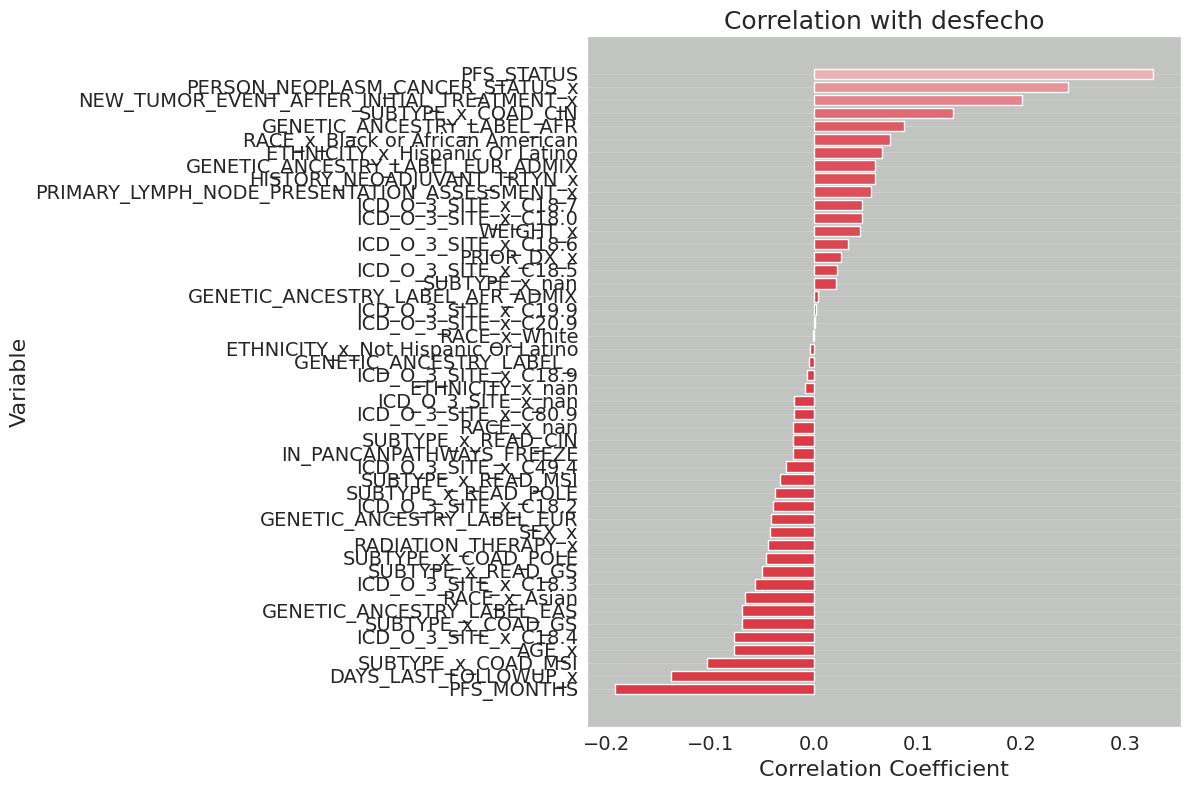

In [65]:
#Plotar o gráfico de correlação
omics_set = set(omics_var)

# 2. Filtra mantendo apenas o que NÃO está no set de ômicas
vars_not_omics = [var for var in df_clean_ohe.columns.tolist() if var not in omics_set]

correlation_plot = plot_correlation_with_target(df_clean_ohe[vars_not_omics], target_col="desfecho")
correlations = df_clean_ohe[vars_not_omics].corr()['desfecho'].drop('desfecho').sort_values(ascending=False)
display(correlations)
correlation_plot

## Divisão Treino e Teste

Iremos rodar três experimentos (02/03/2026): <p>
- Somente com as variáveis clínicas  
- Somente com as variáveis ômicas
- Com todas as variáveis

In [ ]:
#iMPORTANDO OS ARQUIVOS JA GERADO

X_train_omics = pd.read_csv(DIRETORIO_DOWNLOAD + '/train_test/X_train_omics.csv')
X_test_omics = pd.read_csv(DIRETORIO_DOWNLOAD +  '/train_test/X_test_omics.csv')
y_train = pd.read_csv(DIRETORIO_DOWNLOAD + '/train_test/y_train.csv')
y_test = pd.read_csv(DIRETORIO_DOWNLOAD + '/train_test/y_test.csv')



In [14]:
X_train_all = pd.read_csv(DIRETORIO_DOWNLOAD + '/train_test/X_train_all.csv')
X_test_all = pd.read_csv(DIRETORIO_DOWNLOAD +  '/train_test/X_test_all.csv')

In [105]:
X = df_clean_ohe.drop(columns=(["desfecho"] + omics_var))
y = df_clean_ohe['desfecho']
X_train_clinical, X_test_clinical, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [106]:
X = df_clean_ohe.drop(columns=(["desfecho"] + vars_not_omics))
y = df_clean_ohe['desfecho']
X_train_omics, X_test_omics, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [107]:
X = df_clean_ohe.drop(columns="desfecho")
y = df_clean_ohe['desfecho']
X_train_all, X_test_all, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [110]:
# Defina o nome da subpasta onde os arquivos do modelo ficarão guardados
pasta_destino = os.path.join(DIRETORIO_DOWNLOAD, "train_test")

os.makedirs(pasta_destino, exist_ok=True)

dataframes_para_salvar = {
    "X_train_clinical.csv": X_train_clinical,
    "X_test_clinical.csv": X_test_clinical,
    "X_train_omics.csv": X_train_omics,
    "X_test_omics.csv": X_test_omics,
    "X_train_all.csv": X_train_all,
    "X_test_all.csv": X_test_all,
    "y_train.csv": y_train,
    "y_test.csv": y_test
}


for nome_arquivo, df in dataframes_para_salvar.items():
    caminho_completo = os.path.join(pasta_destino, nome_arquivo)
    
    # Salva em CSV. O parâmetro index=False evita exportar o índice como uma coluna extra
    df.to_csv(caminho_completo, index=False)
    
    print(f"Salvo com sucesso: {nome_arquivo}")

print(f"\nTodos os {len(dataframes_para_salvar)} arquivos foram exportados!")

Salvo com sucesso: X_train_clinical.csv
Salvo com sucesso: X_test_clinical.csv
Salvo com sucesso: X_train_omics.csv
Salvo com sucesso: X_test_omics.csv
Salvo com sucesso: X_train_all.csv
Salvo com sucesso: X_test_all.csv
Salvo com sucesso: y_train.csv
Salvo com sucesso: y_test.csv

Todos os 8 arquivos foram exportados!


In [ ]:
#Proporçaõ do desfecho
pd.DataFrame({"Treino Clínicas": y_train_clinical.value_counts()/y_train_clinical.shape[0], 
             "Teste Clínicas": y_test_clinical.value_counts()/y_test_clinical.shape[0],
             "Treino Ômicas": y_train_omics.value_counts()/y_train_omics.shape[0], 
             "Teste Clínicas": y_test_omics.value_counts()/y_test_omics.shape[0],
             "Treino Todas": y_train_all.value_counts()/y_train_all.shape[0], 
             "Teste Clínicas": y_test_all.value_counts()/y_test_all.shape[0]
})

,Treino Clínicas,Teste Clínicas,Treino Ômicas,Treino Todas
desfecho,,,,
0.0,0.843407,0.840764,0.843407,0.843407
1.0,0.156593,0.159236,0.156593,0.156593


Padronização dos Dados

In [108]:
scaler = StandardScaler()
var_to_normalize_clinical = num_var
X_train_clinical.loc[:, var_to_normalize_clinical] = scaler.fit_transform(X_train_clinical[var_to_normalize_clinical])
X_test_clinical.loc[:, var_to_normalize_clinical] = scaler.transform(X_test_clinical[var_to_normalize_clinical])

scaler = StandardScaler()
var_to_normalize_omics = omics_var 
X_train_omics.loc[:, var_to_normalize_omics] = scaler.fit_transform(X_train_omics[var_to_normalize_omics])
X_test_omics.loc[:, var_to_normalize_omics] = scaler.transform(X_test_omics[var_to_normalize_omics])

scaler = StandardScaler()
var_to_normalize_all = num_var + omics_var
X_train_all.loc[:, var_to_normalize_all] = scaler.fit_transform(X_train_all[var_to_normalize_all])
X_test_all.loc[:, var_to_normalize_all] = scaler.transform(X_test_all[var_to_normalize_all])

In [ ]:
#Só ômicas

scaler = StandardScaler()
var_to_normalize_omics =  X_train_omics.columns.tolist()
X_train_omics.loc[:, var_to_normalize_omics] = scaler.fit_transform(X_train_omics[var_to_normalize_omics])
X_test_omics.loc[:, var_to_normalize_omics] = scaler.transform(X_test_omics[var_to_normalize_omics])



#Com todas
scaler = StandardScaler()
var_to_normalize_all = num_var + omics_var
X_train_all.loc[:, var_to_normalize_all] = scaler.fit_transform(X_train_all[var_to_normalize_all])
X_test_all.loc[:, var_to_normalize_all] = scaler.transform(X_test_all[var_to_normalize_all])

## Modelos Locais

Aqui optamos por utilizar uma otimização bayesiana na hiperparametrização devido a <p>
- Possibilidade de explorar funções contínuas durante a busca de hiperparâmetros  
- Algoritmo de busca mais rápido por se apoiar em estatística bayesiana: posteriori = priori + novo_evento  
- É maneiro pra cacete


#### Função Sem Placa de Vídeo

In [109]:
# Silenciar o log detalhado do Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def executar_pipeline_otimizacao(X_train, X_test, y_train, y_test, modelos_selecionados=None):
    
    # Garantir que o y esteja no formato correto (array 1D)
    if isinstance(y_train, (pd.DataFrame, pd.Series)):
        y_train_flat = y_train.values.ravel()
    else:
        y_train_flat = y_train.ravel()

    if isinstance(y_test, (pd.DataFrame, pd.Series)):
        y_test_flat = y_test.values.ravel()
    else:
        y_test_flat = y_test.ravel()

    # --- CONFIGURAÇÃO DOS MODELOS E ESPAÇO DE HIPERPARAMETRIZAÇÃO ---
    
    modelos_disponiveis = {
        # Modelos Inferenciais e Árvore de Decisão -------
        'LogisticRegression': {
            'modelo': LogisticRegression(random_state=42, solver='liblinear'), 
            'params': {
                'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
                'penalty': ['l1', 'l2'], 
                'class_weight': [None, 'balanced'] 
            },
            'n_iter': 20
        },
        'DecisionTree': {
            'modelo': DecisionTreeClassifier(random_state=42),
            'params': {
                'criterion': ['gini', 'entropy'],
                'max_depth': range(2, 15, 1), 
                'min_samples_split': range(2, 20, 2), 
                'min_samples_leaf': range(1, 10, 1),  
                'class_weight': [None, 'balanced']
            },
            'n_iter': 20
        },

        # Modelos de Boosting Machine Learning -------
        'RandomForest': {
            'modelo': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': range(50, 550, 50), 
                'max_depth': range(2, 6, 1), 
                'max_features': ['sqrt', 'log2', 0.5, 0.6, 0.7, 0.8, 0.9], 
            },
            'n_iter': 20  
        },
        'XGBoost': {
            'modelo': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='auc'),
            'params': {
                'n_estimators': range(50, 550, 50), 
                'max_depth': range(2, 6, 1),
                'eta': np.arange(0.01, 0.10, 0.01), 
                'colsample_bytree': np.arange(0.5, 1.0, 0.1), 
                'min_child_weight': range(2, 10, 1), 
                'subsample': np.arange(0.5, 1.0, 0.1), 
                'reg_lambda': [1, 1.5, 2, 5, 10], 
            },
            'n_iter': 20
        },
        'LightGBM': {
            'modelo': lgb.LGBMClassifier(random_state=42, verbose=-1),
            'params': {
                'n_estimators': range(50, 550, 50),
                'max_depth': range(2, 6, 1),
                'learning_rate': np.arange(0.01, 0.10, 0.01),
                'colsample_bytree': np.arange(0.5, 1.0, 0.1),
                'min_child_weight': range(2, 10, 1),
                'subsample': np.arange(0.5, 1.0, 0.1),
                'reg_lambda': [1, 1.5, 2, 5, 10],
            },
            'n_iter': 20
        },
        'CatBoost': {
            'modelo': CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False),
            'params': {
                'iterations': range(50, 550, 50),
                'depth': range(2, 6, 1),
                'learning_rate': np.arange(0.01, 0.10, 0.01),
                'rsm': np.arange(0.5, 1.0, 0.1),
                'subsample': np.arange(0.5, 1.0, 0.1),
                'l2_leaf_reg': [1, 1.5, 2, 5, 10],
            },
            'n_iter': 20
        }
    }

    # --- FILTRO DOS MODELOS SELECIONADOS ---
    if modelos_selecionados is not None:
        # Verifica se o usuário passou algum modelo que não existe no dicionário
        modelos_invalidos = [m for m in modelos_selecionados if m not in modelos_disponiveis.keys()]
        if modelos_invalidos:
            raise ValueError(f"Modelo(s) inválido(s): {modelos_invalidos}. Escolha entre: {list(modelos_disponiveis.keys())}")
        
        # Filtra o dicionário mantendo apenas os modelos da lista
        modelos_a_treinar = {k: v for k, v in modelos_disponiveis.items() if k in modelos_selecionados}
    else:
        # Se não passar nada, roda todos
        modelos_a_treinar = modelos_disponiveis

    # Estruturas para guardar os resultados
    resultados_gerais = []
    modelos_treinados = {}

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f"{'='*70}")
    print(f"INICIANDO PIPELINE DE OTIMIZAÇÃO E TREINO")
    print(f"Modelos selecionados: {list(modelos_a_treinar.keys())}")
    print(f"{'='*70}")

    # Loop pelos modelos
    for nome_modelo, config in modelos_a_treinar.items():
        print(f"\n>>> Processando: {nome_modelo} ...")

        # 1. Função Objetivo do Optuna
        def objective(trial):
            params = {}
            for param_name, param_values in config['params'].items():
                if isinstance(param_values, range):
                    params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
                elif isinstance(param_values, list):
                    params[param_name] = trial.suggest_categorical(param_name, param_values)
                elif isinstance(param_values, np.ndarray):
                    params[param_name] = trial.suggest_float(param_name, param_values.min(), param_values.max())

            model_clone = clone(config['modelo'])
            model_clone.set_params(**params)

            score = cross_val_score(model_clone, X_train, y_train_flat, cv=cv_strategy, scoring='roc_auc', n_jobs=1).mean()
            return score

        # 2. Execução do Estudo do Optuna
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=config['n_iter'], show_progress_bar=True)

        # 3. Melhores Resultados
        best_params = study.best_params
        best_score_cv = study.best_value
        print(f"   [Melhor CV AUC]: {best_score_cv:.4f}")

        # 4. Treinamento do Modelo Final
        modelo_final = clone(config['modelo']).set_params(**best_params)
        modelo_final.fit(X_train, y_train_flat)
        
        modelos_treinados[nome_modelo] = modelo_final

        # 5. Avaliação no Teste
        y_pred = modelo_final.predict(X_test)
        
        try:
            prob_pos = modelo_final.predict_proba(X_test)[:, 1]
            auc_test = roc_auc_score(y_test_flat, prob_pos)
        except:
            auc_test = 0.0 
            
        metricas = {
            "Accuracy": accuracy_score(y_test_flat, y_pred),
            "Precision": precision_score(y_test_flat, y_pred, zero_division=0),
            "Recall": recall_score(y_test_flat, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test_flat, y_pred, zero_division=0),
            "AUC_ROC": auc_test
        }

        resultados_gerais.append({
            'Modelo': nome_modelo, 
            **metricas, 
            'Melhores_Hiperparametros': best_params
        })

    print(f"\n{'='*70}")
    print("CONCLUÍDO!")
    
    return pd.DataFrame(resultados_gerais), modelos_treinados

#### Função para Placa de Vídeo

In [123]:
# Silenciar o log detalhado do Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def executar_pipeline_otimizacao(X_train, X_test, y_train, y_test, modelos_selecionados=None):
    
    # Garantir que o y esteja no formato correto (array 1D)
    if isinstance(y_train, (pd.DataFrame, pd.Series)):
        y_train_flat = y_train.values.ravel()
    else:
        y_train_flat = y_train.ravel()

    if isinstance(y_test, (pd.DataFrame, pd.Series)):
        y_test_flat = y_test.values.ravel()
    else:
        y_test_flat = y_test.ravel()

    # --- CONFIGURAÇÃO DOS MODELOS E ESPAÇO DE HIPERPARAMETRIZAÇÃO ---
    
    modelos_disponiveis = {
        # Modelos Inferenciais e Árvore de Decisão -------
        'LogisticRegression': {
            'modelo': LogisticRegression(random_state=42, solver='liblinear'), 
            'params': {
                'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
                'penalty': ['l1', 'l2'], 
                'class_weight': [None, 'balanced'] 
            },
            'n_iter': 20
        },
        'DecisionTree': {
            'modelo': DecisionTreeClassifier(random_state=42),
            'params': {
                'criterion': ['gini', 'entropy'],
                'max_depth': range(2, 15, 1), 
                'min_samples_split': range(2, 20, 2), 
                'min_samples_leaf': range(1, 10, 1),  
                'class_weight': [None, 'balanced']
            },
            'n_iter': 20
        },

        # Modelos de Boosting Machine Learning -------
        'RandomForest': {
            # CPU AQUI: n_jobs=-1 usa todos os núcleos do seu processador para criar as árvores em paralelo
            'modelo': RandomForestClassifier(random_state=42, n_jobs=-1),
            'params': {
                'n_estimators': range(50, 550, 50), 
                'max_depth': range(2, 6, 1), 
                'max_features': ['sqrt', 'log2', 0.5, 0.6, 0.7, 0.8, 0.9], 
            },
            'n_iter': 20  
        },
        
        'XGBoost': {
            # GPU AQUI: tree_method='hist' e device='cuda' ativam a sua RTX 4050
            'modelo': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='auc', tree_method='hist', device='cuda'),
            'params': {
                'n_estimators': range(50, 550, 50), 
                'max_depth': range(2, 6, 1),
                'eta': np.arange(0.01, 0.10, 0.01), 
                'colsample_bytree': np.arange(0.5, 1.0, 0.1), 
                'min_child_weight': range(2, 10, 1), 
                'subsample': np.arange(0.5, 1.0, 0.1), 
                'reg_lambda': [1, 1.5, 2, 5, 10], 
            },
            'n_iter': 20
        },
        
        'LightGBM': {
            # GPU AQUI: device_type='gpu' ativa a placa de vídeo. 
            # ATENÇÃO: O LightGBM exige que a versão instalada no WSL tenha sido compilada com suporte a GPU.
            'modelo': lgb.LGBMClassifier(random_state=42, verbose=-1, device_type='gpu'),
            'params': {
                'n_estimators': range(50, 550, 50),
                'max_depth': range(2, 6, 1),
                'learning_rate': np.arange(0.01, 0.10, 0.01),
                'colsample_bytree': np.arange(0.5, 1.0, 0.1),
                'min_child_weight': range(2, 10, 1),
                'subsample': np.arange(0.5, 1.0, 0.1),
                'reg_lambda': [1, 1.5, 2, 5, 10],
            },
            'n_iter': 20
        },
        
        'CatBoost': {
            # GPU AQUI: task_type='GPU' é tudo o que o CatBoost precisa
            'modelo': CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False, task_type='GPU',bootstrap_type='Bernoulli'),
            'params': {
                'iterations': range(50, 550, 50),
                'depth': range(2, 6, 1),
                'learning_rate': np.arange(0.01, 0.10, 0.01),
                #'rsm': np.arange(0.5, 1.0, 0.1), Não aplicável para GPU
                'subsample': np.arange(0.5, 1.0, 0.1),
                'l2_leaf_reg': [1, 1.5, 2, 5, 10],
            },
            'n_iter': 20
        }
    }

    # --- FILTRO DOS MODELOS SELECIONADOS ---
    if modelos_selecionados is not None:
        modelos_invalidos = [m for m in modelos_selecionados if m not in modelos_disponiveis.keys()]
        if modelos_invalidos:
            raise ValueError(f"Modelo(s) inválido(s): {modelos_invalidos}. Escolha entre: {list(modelos_disponiveis.keys())}")
        
        modelos_a_treinar = {k: v for k, v in modelos_disponiveis.items() if k in modelos_selecionados}
    else:
        modelos_a_treinar = modelos_disponiveis

    resultados_gerais = []
    modelos_treinados = {}

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f"{'='*70}")
    print(f"INICIANDO PIPELINE DE OTIMIZAÇÃO E TREINO (ACELERAÇÃO ATIVADA)")
    print(f"Modelos selecionados: {list(modelos_a_treinar.keys())}")
    print(f"{'='*70}")

    for nome_modelo, config in modelos_a_treinar.items():
        print(f"\n>>> Processando: {nome_modelo} ...")

        def objective(trial):
            params = {}
            for param_name, param_values in config['params'].items():
                if isinstance(param_values, range):
                    params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
                elif isinstance(param_values, list):
                    params[param_name] = trial.suggest_categorical(param_name, param_values)
                elif isinstance(param_values, np.ndarray):
                    params[param_name] = trial.suggest_float(param_name, param_values.min(), param_values.max())

            model_clone = sk_clone(config['modelo'])
            model_clone.set_params(**params)

            # Mantemos n_jobs=1 no cross_val_score para não sobrecarregar a memória VRAM da GPU 
            # rodando vários folds simultaneamente. A paralelização ocorrerá dentro do próprio modelo.
            score = cross_val_score(model_clone, X_train, y_train_flat, cv=cv_strategy, scoring='roc_auc', n_jobs=1).mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=config['n_iter'], show_progress_bar=True)

        best_params = study.best_params
        best_score_cv = study.best_value
        print(f"   [Melhor CV AUC]: {best_score_cv:.4f}")

        modelo_final = sk_clone(config['modelo']).set_params(**best_params)
        modelo_final.fit(X_train, y_train_flat)
        
        modelos_treinados[nome_modelo] = modelo_final

        y_pred = modelo_final.predict(X_test)
        
        try:
            prob_pos = modelo_final.predict_proba(X_test)[:, 1]
            auc_test = roc_auc_score(y_test_flat, prob_pos)
        except:
            auc_test = 0.0 
            
        metricas = {
            "Accuracy": accuracy_score(y_test_flat, y_pred),
            "Precision": precision_score(y_test_flat, y_pred, zero_division=0),
            "Recall": recall_score(y_test_flat, y_pred, zero_division=0),
            "F1-Score": f1_score(y_test_flat, y_pred, zero_division=0),
            "AUC_ROC": auc_test
        }

        resultados_gerais.append({
            'Modelo': nome_modelo, 
            **metricas, 
            'Melhores_Hiperparametros': best_params
        })

    print(f"\n{'='*70}")
    print("CONCLUÍDO!")
    
    return pd.DataFrame(resultados_gerais), modelos_treinados

In [124]:
X_train_clinical = X_train_clinical.astype(np.float32)
X_test_clinical = X_test_clinical.astype(np.float32)

selecao_modelos = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']
df_resultados_clinical, dict_modelos_clinical = executar_pipeline_otimizacao(X_train_clinical, X_test_clinical, y_train, y_test, modelos_selecionados = selecao_modelos)

INICIANDO PIPELINE DE OTIMIZAÇÃO E TREINO (ACELERAÇÃO ATIVADA)
Modelos selecionados: ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']

>>> Processando: DecisionTree ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.679495:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.679495:  10%|█         | 2/20 [00:00<00:00, 18.36it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_nam

   [Melhor CV AUC]: 0.7154

>>> Processando: RandomForest ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.77504:   5%|▌         | 1/20 [00:00<00:14,  1.34it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 1. Best value: 0.775043:  10%|█         | 2/20 [00:02<00:23,  1.29s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 50

   [Melhor CV AUC]: 0.7768

>>> Processando: XGBoost ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:44:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:44:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:44:17] WARNING: /__w/xgboost/xgboost/src/learn

   [Melhor CV AUC]: 0.7828

>>> Processando: CatBoost ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.748274:   5%|▌         | 1/20 [00:10<03:11, 10.05s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.748274:  10%|█         | 2/20 [01:29<15:13, 50.74s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 5

   [Melhor CV AUC]: 0.7844

CONCLUÍDO!


In [125]:
dict_modelos_clinical

{'DecisionTree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=9,
                        min_samples_split=14, random_state=42),
 'RandomForest': RandomForestClassifier(max_depth=5, n_estimators=500, n_jobs=-1,
                        random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.5052159431023634, device='cuda',
               early_stopping_rounds=None, enable_categorical=False,
               eta=0.01834793103629804, eval_metric='auc', feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
               max_leaves=None, min_child_weight=7, missing=nan,
               mono

In [128]:
# 1. Cria uma pasta organizada
pasta_destino = DIRETORIO_DOWNLOAD + "/models0203" 
os.makedirs(pasta_destino, exist_ok=True)
# 3. Loop para salvar cada modelo individualmente
list_experimentos = ['clinical']

for experimento in list_experimentos:
    # Constrói o nome da variável como string
    nome_da_variavel_str = f'dict_modelos_{experimento}'
    
    # Tenta pegar o dicionário real usando globals()
    # Se suas variáveis estiverem no escopo global (o padrão do Jupyter), isso funcionará
    if nome_da_variavel_str in globals():
        dicionario_atual = globals()[nome_da_variavel_str]
        
        for nome_modelo, objeto_modelo in dicionario_atual.items():
            # Adicionei o nome do experimento ao arquivo para evitar sobrescrever 
            # se houver modelos com mesmo nome em dicionários diferentes
            filename = f"{nome_modelo}_{experimento}.pkl" 
            caminho_arquivo = os.path.join(pasta_destino, filename)
            
            # Salva no disco
            joblib.dump(objeto_modelo, caminho_arquivo)
            print(f"{filename} salvo com sucesso!")
    else:
        print(f"Aviso: A variável '{nome_da_variavel_str}' não foi encontrada.")

DecisionTree_clinical.pkl salvo com sucesso!
RandomForest_clinical.pkl salvo com sucesso!
XGBoost_clinical.pkl salvo com sucesso!
CatBoost_clinical.pkl salvo com sucesso!


In [129]:
X_train_omics = X_train_omics.astype(np.float32)
X_test_omics = X_test_omics.astype(np.float32)

selecao_modelos = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']
df_resultados_omics, dict_modelos_omics = executar_pipeline_otimizacao(X_train_omics, X_test_omics, y_train, y_test, modelos_selecionados = selecao_modelos)

INICIANDO PIPELINE DE OTIMIZAÇÃO E TREINO (ACELERAÇÃO ATIVADA)
Modelos selecionados: ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']

>>> Processando: DecisionTree ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.496665:   5%|▌         | 1/20 [00:08<02:37,  8.31s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 1. Best value: 0.553627:  10%|█         | 2/20 [00:13<01:52,  6.23s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[p

   [Melhor CV AUC]: 0.5708

>>> Processando: RandomForest ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.600014:   5%|▌         | 1/20 [00:29<09:29, 29.95s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 1. Best value: 0.611862:  10%|█         | 2/20 [01:26<13:43, 45.75s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 5

   [Melhor CV AUC]: 0.6376

>>> Processando: XGBoost ...


...

   [Melhor CV AUC]: 0.6807


/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:31:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



>>> Processando: CatBoost ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.613596:   5%|▌         | 1/20 [00:46<14:49, 46.82s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 1. Best value: 0.623056:  10%|█         | 2/20 [02:24<23:03, 76.86s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 5

   [Melhor CV AUC]: 0.6690

CONCLUÍDO!


In [132]:
# 1. Cria uma pasta organizada
pasta_destino = DIRETORIO_DOWNLOAD + "/models0203" 
os.makedirs(pasta_destino, exist_ok=True)
# 3. Loop para salvar cada modelo individualmente
list_experimentos = ['omics']

for experimento in list_experimentos:
    # Constrói o nome da variável como string
    nome_da_variavel_str = f'dict_modelos_{experimento}'
    
    # Tenta pegar o dicionário real usando globals()
    # Se suas variáveis estiverem no escopo global (o padrão do Jupyter), isso funcionará
    if nome_da_variavel_str in globals():
        dicionario_atual = globals()[nome_da_variavel_str]
        
        for nome_modelo, objeto_modelo in dicionario_atual.items():
            # Adicionei o nome do experimento ao arquivo para evitar sobrescrever 
            # se houver modelos com mesmo nome em dicionários diferentes
            filename = f"{nome_modelo}_{experimento}.pkl" 
            caminho_arquivo = os.path.join(pasta_destino, filename)
            
            # Salva no disco
            joblib.dump(objeto_modelo, caminho_arquivo)
            print(f"{filename} salvo com sucesso!")
    else:
        print(f"Aviso: A variável '{nome_da_variavel_str}' não foi encontrada.")

DecisionTree_omics.pkl salvo com sucesso!
RandomForest_omics.pkl salvo com sucesso!
XGBoost_omics.pkl salvo com sucesso!
CatBoost_omics.pkl salvo com sucesso!


In [ ]:
display(df_resultados_clinical.sort_values(by='AUC_ROC', ascending=False))
display(df_resultados_omics.sort_values(by='AUC_ROC', ascending=False))

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC_ROC,Melhores_Hiperparametros
3,CatBoost,0.859873,1.000000,0.12,0.214286,0.790606,"{'iterations': 50, 'depth': 3, 'learning_rate'..."
2,XGBoost,0.859873,1.000000,0.12,0.214286,0.773333,"{'n_estimators': 200, 'max_depth': 4, 'eta': 0..."
1,RandomForest,0.853503,1.000000,0.08,0.148148,0.763636,"{'n_estimators': 500, 'max_depth': 5, 'max_fea..."
0,DecisionTree,0.662420,0.240741,0.52,0.329114,0.627273,"{'criterion': 'gini', 'max_depth': 5, 'min_sam..."


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC_ROC,Melhores_Hiperparametros
2,XGBoost,0.821656,0.000000,0.00,0.000000,0.754242,"{'n_estimators': 400, 'max_depth': 4, 'eta': 0..."
0,DecisionTree,0.796178,0.111111,0.04,0.058824,0.695909,"{'criterion': 'entropy', 'max_depth': 3, 'min_..."
3,CatBoost,0.840764,0.000000,0.00,0.000000,0.640303,"{'iterations': 100, 'depth': 4, 'learning_rate..."
1,RandomForest,0.840764,0.000000,0.00,0.000000,0.596667,"{'n_estimators': 350, 'max_depth': 4, 'max_fea..."


In [142]:
df_resultados_all, dict_modelos_all = df_resultados_omics, dict_modelos_omics

In [ ]:
X_train_all = X_train_all.astype(np.float32)
X_test_all = X_test_all.astype(np.float32)

selecao_modelos = ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']
df_resultados_all, dict_modelos_all = executar_pipeline_otimizacao(X_train_all, X_test_all, y_train, y_test, modelos_selecionados = selecao_modelos)

INICIANDO PIPELINE DE OTIMIZAÇÃO E TREINO (ACELERAÇÃO ATIVADA)
Modelos selecionados: ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']

>>> Processando: DecisionTree ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.538521:   5%|▌         | 1/20 [00:08<02:36,  8.23s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 1. Best value: 0.598276:  10%|█         | 2/20 [00:17<02:43,  9.11s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [2, 19] and step=2, but the range is not divisible by `step`. It will be replaced with [2, 18].
  params[p

   [Melhor CV AUC]: 0.6508

>>> Processando: RandomForest ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.618968:   5%|▌         | 1/20 [00:04<01:27,  4.58s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 1. Best value: 0.69407:  10%|█         | 2/20 [00:35<06:01, 20.08s/it] /tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 5

   [Melhor CV AUC]: 0.7056

>>> Processando: XGBoost ...


...

   [Melhor CV AUC]: 0.7443


/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [01:06:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



>>> Processando: CatBoost ...


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.694118:   5%|▌         | 1/20 [01:44<32:57, 104.06s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50, 500].
  params[param_name] = trial.suggest_int(param_name, param_values.start, param_values.stop - 1, step=param_values.step)
Best trial: 0. Best value: 0.694118:  10%|█         | 2/20 [03:30<31:39, 105.54s/it]/tmp/ipykernel_16944/3494712198.py:127: UserWarning: The distribution is specified by [50, 549] and step=50, but the range is not divisible by `step`. It will be replaced with [50,

   [Melhor CV AUC]: 0.7250

CONCLUÍDO!


In [147]:
df_resultados_all.sort_values(by='AUC_ROC', ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC_ROC,Melhores_Hiperparametros
2,XGBoost,0.847134,1.000000,0.04,0.076923,0.780909,"{'n_estimators': 400, 'max_depth': 4, 'eta': 0..."
3,CatBoost,0.840764,0.000000,0.00,0.000000,0.699394,"{'iterations': 100, 'depth': 4, 'learning_rate..."
1,RandomForest,0.840764,0.000000,0.00,0.000000,0.661212,"{'n_estimators': 300, 'max_depth': 2, 'max_fea..."
0,DecisionTree,0.777070,0.272727,0.24,0.255319,0.565152,"{'criterion': 'gini', 'max_depth': 9, 'min_sam..."


In [144]:
# 1. Cria uma pasta organizada
pasta_destino = DIRETORIO_DOWNLOAD + "/models0203" 
os.makedirs(pasta_destino, exist_ok=True)
# 3. Loop para salvar cada modelo individualmente
list_experimentos = ['all']

for experimento in list_experimentos:
    # Constrói o nome da variável como string
    nome_da_variavel_str = f'dict_modelos_{experimento}'
    
    # Tenta pegar o dicionário real usando globals()
    # Se suas variáveis estiverem no escopo global (o padrão do Jupyter), isso funcionará
    if nome_da_variavel_str in globals():
        dicionario_atual = globals()[nome_da_variavel_str]
        
        for nome_modelo, objeto_modelo in dicionario_atual.items():
            # Adicionei o nome do experimento ao arquivo para evitar sobrescrever 
            # se houver modelos com mesmo nome em dicionários diferentes
            filename = f"{nome_modelo}_{experimento}.pkl" 
            caminho_arquivo = os.path.join(pasta_destino, filename)
            
            # Salva no disco
            joblib.dump(objeto_modelo, caminho_arquivo)
            print(f"{filename} salvo com sucesso!")
    else:
        print(f"Aviso: A variável '{nome_da_variavel_str}' não foi encontrada.")

DecisionTree_all.pkl salvo com sucesso!
RandomForest_all.pkl salvo com sucesso!
XGBoost_all.pkl salvo com sucesso!
CatBoost_all.pkl salvo com sucesso!


## Explicabilidade

In [13]:
#Importando os modelos para trabalho

xgboost_omics = joblib.load(DIRETORIO_DOWNLOAD+'/models0203/XGBoost_omics.pkl')
xgboost_all = joblib.load(DIRETORIO_DOWNLOAD+'/models0203/XGBoost_all.pkl')

/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:2219: UserWarning: [18:23:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  raw = xgb_model.save_raw(raw_format="ubj")


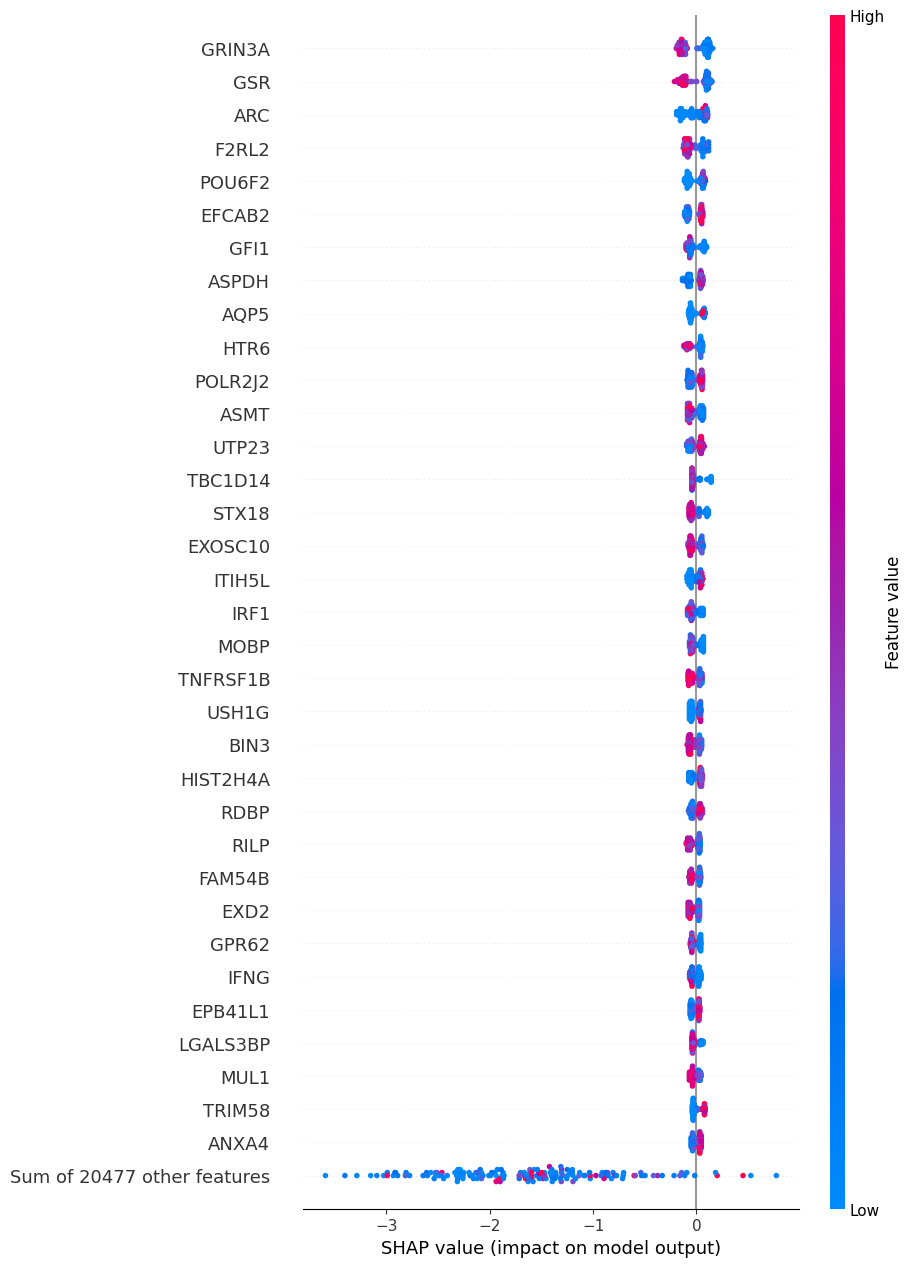

In [10]:
modelo = xgboost_omics
X = X_test_omics 

modelo.set_params(device='cuda')
# 3. Inicialize o Explainer do SHAP
# Nota: shap.Explainer escolhe automaticamente o melhor algoritmo. 
# Se você tiver certeza que é um modelo baseado em árvore (XGBoost, RandomForest, LightGBM),
# você pode usar diretamente explainer = shap.TreeExplainer(modelo) para ser mais rápido.
explainer = shap.TreeExplainer(modelo)

# 4. Calcule os valores SHAP
# Isso pode levar algum tempo dependendo do tamanho do X e da complexidade do modelo.
shap_values = explainer(X)

# 5. Crie e exiba o gráfico Beeswarm
# Você pode ajustar o 'max_display' para mostrar mais ou menos variáveis no eixo Y.
shap.plots.beeswarm(shap_values, max_display=35)

# Exibe o gráfico na tela
plt.show()

/home/vcamargo/genomics/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:2219: UserWarning: [18:36:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  raw = xgb_model.save_raw(raw_format="ubj")


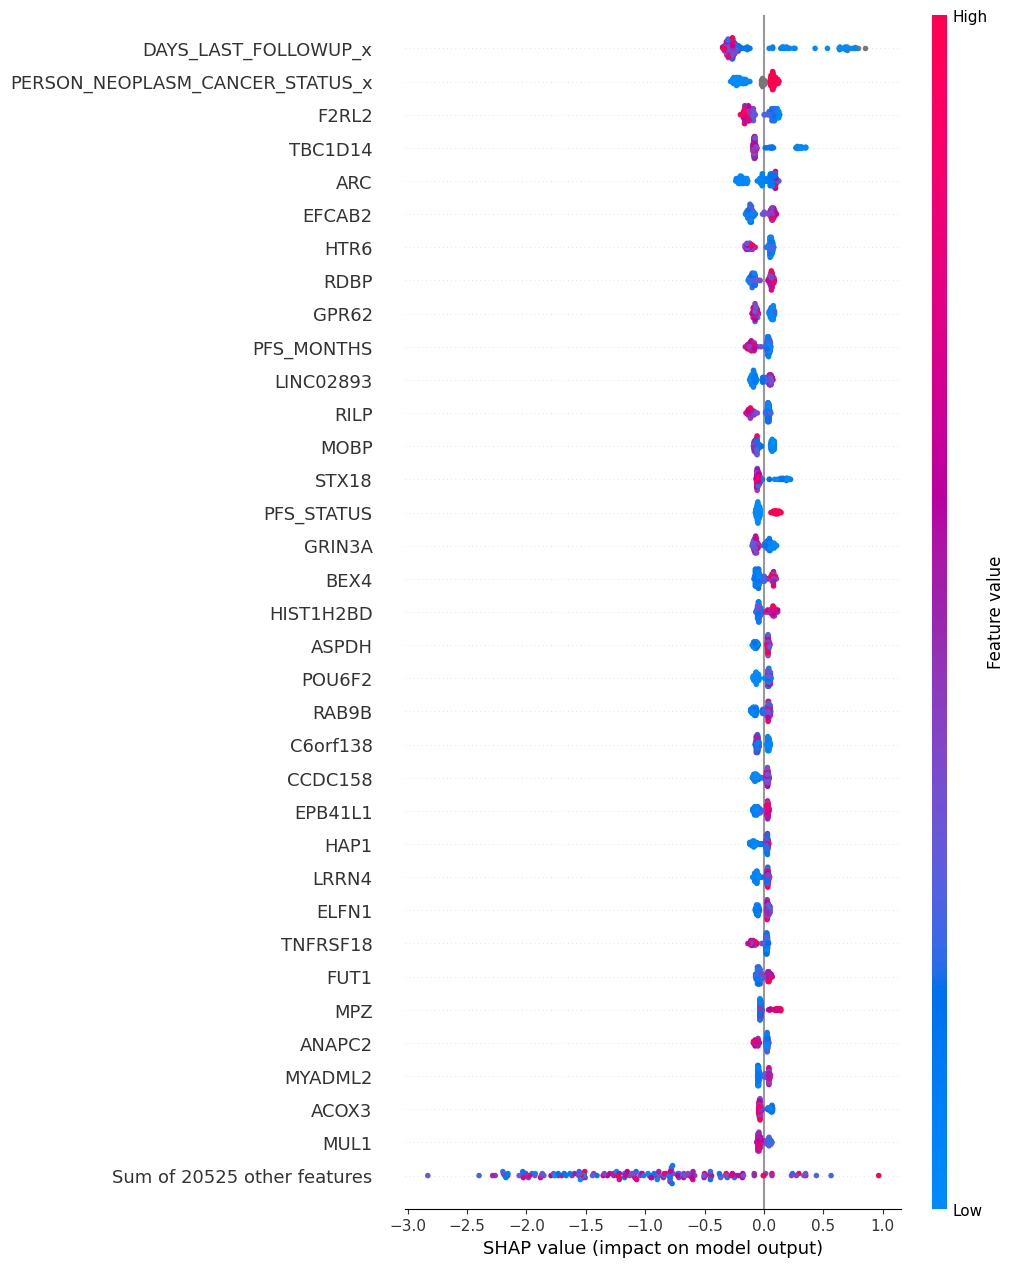

In [19]:
modelo = xgboost_all
X = X_test_all 

modelo.set_params(device='cuda')
# 3. Inicialize o Explainer do SHAP
# Nota: shap.Explainer escolhe automaticamente o melhor algoritmo. 
# Se você tiver certeza que é um modelo baseado em árvore (XGBoost, RandomForest, LightGBM),
# você pode usar diretamente explainer = shap.TreeExplainer(modelo) para ser mais rápido.
explainer = shap.TreeExplainer(modelo)

# 4. Calcule os valores SHAP
# Isso pode levar algum tempo dependendo do tamanho do X e da complexidade do modelo.
shap_values = explainer(X)

# 5. Crie e exiba o gráfico Beeswarm
# Você pode ajustar o 'max_display' para mostrar mais ou menos variáveis no eixo Y.
shap.plots.beeswarm(shap_values, max_display=35)

# Exibe o gráfico na tela
plt.show()

In [ ]:
X

In [12]:
display(shap_values.shape)
display(X_test_omics.shape)


(157, 20511)

(157, 20511)